In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn import datasets
iris=datasets.load_iris()

x=iris['data'][:,(2,3)]
y=(iris['target']==2).astype(np.float64)

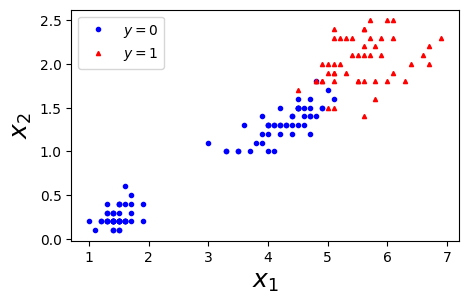

In [7]:
plt.figure(figsize=(5,3))
plt.plot(x[y==0,0],x[y==0,1],'bo',markersize=3,label='$y=0$')
plt.plot(x[y==1,0],x[y==1,1],'r^',markersize=3,label='$y=1$')
plt.legend(loc='upper left')
plt.xlabel('$x_1$',fontsize=18)
plt.ylabel('$x_2$',fontsize=18)
plt.show()

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

svm_clf=Pipeline([
    ('scal',StandardScaler()),
    ('lin_svc',LinearSVC(C=1,loss='hinge',random_state=1))
])

svm_clf.fit(x,y)
svm_clf['lin_svc'].intercept_,svm_clf['lin_svc'].coef_

(array([-2.5053212]), array([[1.63336059, 2.38799535]]))

In [9]:
svm_clf.score(x,y)

0.96

In [10]:
svm_clf.predict([[5.5,1.7]])

array([1.])

In [11]:
def plot_predictions(model,x,y):
  x1s=np.linspace(x.min(axis=0)[0]-0.05,x.max(axis=0)[0]+0.05,1000)
  x2s=np.linspace(x.min(axis=0)[1]-0.05,x.max(axis=0)[1]+0.05,1000)
  x1,x2=np.meshgrid(x1s,x2s)
  X_new=np.c_[x1.ravel(),x2.ravel()]

  y_pred=model.predict(X_new).reshape(x1.shape)
  plt.contourf(x1,x2,y_pred,cmap=plt.cm.brg,alpha=0.2)

  y_decision=model.decision_function(X_new).reshape(x1.shape)
  plt.contourf(x1,x2,y_decision,colors='k',levels=[-1,0,1],linestyles=['--','-','--'],alpha=0.8)

  plt.plot(x[y==0,0],x[y==0,1],'bo',markersize=3,label='$y=0$')
  plt.plot(x[y==1,0],x[y==1,1],'r^',markersize=3,label='$y=1$')
  plt.legend(loc='upper left')

  plt.xlabel('$x_1$',fontsize=18)
  plt.ylabel('$x_2$',fontsize=18)

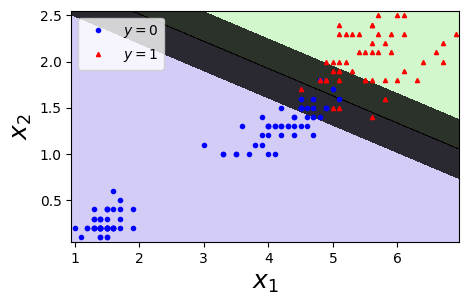

In [12]:
plt.figure(figsize=(5,3))
plot_predictions(svm_clf,x,y)
plt.show()

In [15]:
from sklearn.svm import SVC
svc_clf=Pipeline([
    ('scal',StandardScaler()),
    ('lin_svc',SVC(kernel='linear',random_state=1,C=1))
])

svc_clf.fit(x,y)
svc_clf['lin_svc'].intercept_,svc_clf['lin_svc'].coef_

(array([-2.84959514]), array([[2.09352075, 2.44252199]]))

In [16]:
svc_clf.score(x,y)

0.9533333333333334

In [17]:
svc_clf.predict([[5.5,1.7]])

array([1.])

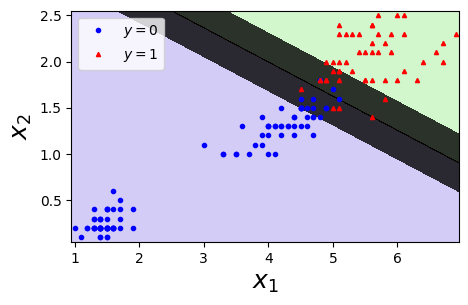

In [18]:
plt.figure(figsize=(5,3))
plot_predictions(svc_clf,x,y)
plt.show()

In [23]:
from sklearn.linear_model import SGDClassifier

sgd_clf=Pipeline([
    ('scal',StandardScaler()),
    ('lin_svc',SGDClassifier(loss='hinge',alpha=1/(1*len(y)),random_state=1))
])

sgd_clf.fit(x,y)
sgd_clf['lin_svc'].intercept_,svc_clf['lin_svc'].coef_

(array([-3.41874739]), array([[2.32563254, 2.69470285]]))

In [24]:
sgd_clf.score(x,y)

0.9666666666666667

In [25]:
sgd_clf.predict([[5.5,1.7]])

array([1.])

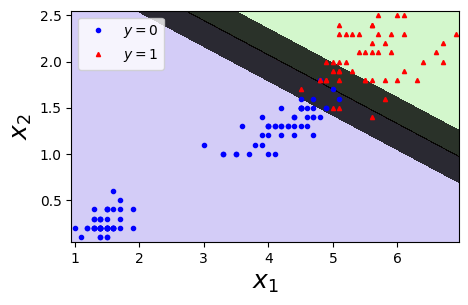

In [26]:
plt.figure(figsize=(5,3))
plot_predictions(sgd_clf,x,y)
plt.show()